In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("../utils")
from plotting_utils import format_top_3, plot_metric_grouped_by, plot_bio_vs_batch_correction

In [3]:
%load_ext autoreload
%autoreload 2

In [ ]:
base_path = "/home/mila/m/myriam.lizotte/RF-MALI"
mali_path = "/home/mila/m/myriam.lizotte/MALI"
scratch_path = "/home/mila/m/myriam.lizotte/scratch/RF-MALI"

# save_name = f"ablation_labels_bad_kema/9092696" #dataset}".format(dataset = dataset_name)
# save_path = f"{scratch_path}/results/{save_name}"


load results

In [53]:
exp = "ablation_labels/9110781"
results_path = f"/home/mila/m/myriam.lizotte/scratch/RF-MALI/results/{exp}"

# load results
results_df = pd.read_csv(f"{results_path}/simulated_multimodal_results.csv")

# in the df, replace "_" with " " 
results_df['split'] = results_df['split'].str.replace('_', ' ')
results_df.columns = results_df.columns.str.replace('_', ' ')

# # convert relevant columns to numeric
num_cols = results_df.columns.difference(['model', 'dataset', 'split', 'seed'])
results_df[num_cols] = results_df[num_cols].apply(pd.to_numeric, errors='coerce')

# take the abs for silhouette domain because it should be low, doesnt matter the sign
results_df['Silhouette domain'] = results_df['Silhouette domain'].abs()

# remove RFMALI
# methods_to_remove= ["RFMALI"]
# results_df = results_df[~results_df["model"].isin(methods_to_remove)]
results_df

,seed,label mask fraction,split,dataset,model,FOSCTTM,Silhouette domain,Accuracy missing,Accuracy visible,Alignment score,Time seconds,Peak memory MB
0,690349.0,0.1,random,balance_scale,RFMALI,0.502710,0.001300,0.583333,0.651327,0.917067,17.417911,105.996945
1,690349.0,0.1,random,balance_scale,FoSTA,0.502453,0.001117,0.583333,0.697345,0.726400,32.774340,117.348086
2,690349.0,0.1,random,balance_scale,MALI,0.500291,0.001560,0.383333,0.467257,1.014000,11.997241,120.734318
3,690349.0,0.1,random,balance_scale,Pamona,NaN,NaN,NaN,NaN,NaN,9.373554,43.197263
4,690349.0,0.1,random,balance_scale,KEMArbf,0.480769,0.009713,0.650000,0.706195,0.000000,0.642028,1.493795
...,...,...,...,...,...,...,...,...,...,...,...,...
11419,29501205.0,1.0,add noise features,tic-tac-toe,FoSTA,0.501534,0.679194,0.653766,0.500000,0.000000,48.418112,307.685295
11420,29501205.0,1.0,add noise features,tic-tac-toe,MALI,0.443053,0.008997,0.712343,1.000000,0.914845,6.800788,277.173352
11421,29501205.0,1.0,add noise features,tic-tac-toe,Pamona,0.477054,0.002812,0.651674,0.500000,0.988298,128.254200,147.422905
11422,29501205.0,1.0,add noise features,tic-tac-toe,KEMArbf,0.439113,0.338963,0.661088,1.000000,0.009944,0.898534,4.720430


In [49]:
results_df.value_counts(["split"], sort=True)

split                 
alternating importance    1650
add noise features        1605
distort                   1582
importance                1576
random                    1575
rotate                    1531
Name: count, dtype: int64

In [33]:
results_df["split"].unique()

array(['random', 'importance', '1.4829158782958984',
       'alternating importance', 'add noise features', 'distort',
       'rotate'], dtype=object)

average over all datasets

In [8]:
summary_df = results_df.groupby(['split','model', 'label mask fraction'])[num_cols].mean()
summary_df_std = results_df.groupby(['split','model', "label mask fraction"])[num_cols].std()
summary_df

Accuracy missing  \
split              model  label mask fraction                     
add noise features FoSTA  0.10                         0.620335   
                          0.25                         0.630141   
                          0.50                         0.656062   
                          0.75                         0.706436   
                          0.90                         0.717164   
...                                                         ...   
rotate             RFMALI 0.50                         0.809270   
                          0.75                         0.795502   
                          0.90                         0.756705   
                          0.99                         0.683885   
                          1.00                         0.671786   

                                               Accuracy visible  \
split              model  label mask fraction                     
add noise features FoSTA  0.10                         0.642275   
                          0.25                         0.653182   
                          0.50                         0.687089   
                          0.75                         0.737288   
                          0.90                         0.751330   
...                                                         ...   
rotate             RFMALI 0.50                         0.875055   
                          0.75                         0.865229   
                          0.90                         0.833197   
                          0.99                         0.666879   
                          1.00                         0.545752   

                                               Alignment score   FOSCTTM  \
split              model  label mask fraction                              
add noise features FoSTA  0.10                        0.349661  0.202546   
                          0.25                        0.371082  0.201457   
                          0.50                        0.436677  0.203767   
                          0.75                        0.541165  0.203800   
                          0.90                        0.666251  0.241998   
...                                                        ...       ...   
rotate             RFMALI 0.50                        0.674766  0.200510   
                          0.75                        0.633875  0.222503   
                          0.90                        0.623710  0.267653   
                          0.99                        0.131720  0.352675   
                          1.00                        0.069254  0.377663   

                                               Peak memory MB  \
split              model  label mask fraction                   
add noise features FoSTA  0.10                      98.254076   
                          0.25                     104.931625   
                          0.50                     101.770592   
                          0.75                      99.905995   
                          0.90                      98.502052   
...                                                       ...   
rotate             RFMALI 0.50                      79.226322   
                          0.75                      76.267100   
                          0.90                      74.501211   
                          0.99                      69.888100   
                          1.00                      71.349013   

                                               Silhouette domain  \
split              model  label mask fraction                      
add noise features FoSTA  0.10                          0.038793   
                          0.25                          0.034780   
                          0.50                          0.028534   
                          0.75                          0.019570   
                          0.90                          0.01

In [9]:
# clean summary_df 

def clean_summary_df(df):
    # remove "RFMALI" 
    df = df.loc[df.index.get_level_values('model') != 'RFMALI']

    cols_to_keep = ["Accuracy missing", "Alignment score", "FOSCTTM"]
    # rename Accuracy missing to Accuracy
    df = df[cols_to_keep]
    df = df.rename(columns={"Accuracy missing": "Accuracy"})
    return df

summary_df = clean_summary_df(summary_df)
summary_df_std = clean_summary_df(summary_df_std)

In [10]:
summary_df_fmt = format_top_3(summary_df)

import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    print(summary_df_fmt.to_latex(
        escape=False,
        multirow=True,
        float_format="%.3f"
    )) 

# then copy the output latex table into a .tex file for inclusion in the paper

\begin{tabular}{llllll}
\toprule
 &  &  & Accuracy & Alignment score & FOSCTTM \\
split & model & label mask fraction &  &  &  \\
\midrule
\multirow[t]{35}{*}{add noise features} & \multirow[t]{7}{*}{FoSTA} & 0.100000 & 0.620 & 0.350 & 0.203 \\
 &  & 0.250000 & 0.630 & 0.371 & 0.201 \\
 &  & 0.500000 & 0.656 & 0.437 & 0.204 \\
 &  & 0.750000 & 0.706 & 0.541 & 0.204 \\
 &  & 0.900000 & 0.717 & 0.666 & 0.242 \\
 &  & 0.990000 & 0.656 & 0.060 & 0.317 \\
 &  & 1.000000 & 0.643 & 0.058 & 0.349 \\
\cline{2-6}
 & \multirow[t]{7}{*}{KEMAlin} & 0.100000 & 0.543 & 0.219 & 0.415 \\
 &  & 0.250000 & 0.512 & 0.190 & 0.413 \\
 &  & 0.500000 & 0.498 & 0.006 & 0.425 \\
 &  & 0.750000 & 0.443 & 0.000 & 0.449 \\
 &  & 0.900000 & 0.380 & 0.000 & 0.468 \\
 &  & 0.990000 & 0.397 & 0.000 & 0.485 \\
 &  & 1.000000 & 0.408 & 0.000 & 0.487 \\
\cline{2-6}
 & \multirow[t]{7}{*}{KEMArbf} & 0.100000 & 0.504 & 0.257 & 0.395 \\
 &  & 0.250000 & 0.404 & 0.126 & 0.406 \\
 &  & 0.500000 & 0.398 & 0.027 & 0.426 \\
 &  &

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:211: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['0.620' '0.630' '0.656' '0.706' '0.717' '0.656' '0.643' '0.543' '0.512'
 '0.498' '0.443' '0.380' '0.397' '0.408' '0.504' '0.404' '0.398' '0.381'
 '0.362' '0.354' '0.379' '0.684' '0.684' '0.711' '0.697' '0.673' '0.630'
 '0.625' '0.666' '0.650' '0.652' '0.666' '0.666' '0.657' '0.670' '0.781'
 '0.761' '0.764' '0.740' '0.719' '0.668' '0.643' '0.544' '0.526' '0.439'
 '0.393' '0.372' '0.385' '0.388' '0.468' '0.466' '0.446' '0.422' '0.443'
 '0.455' '0.439' '0.670' '0.637' '0.641' '0.645' '0.626' '0.603' '0.607'
 '0.663' '0.645' '0.675' '0.677' '0.669' '0.672' '0.685' '0.760' '0.755'
 '0.763' '0.765' '0.738' '0.662' '0.670' '0.605' '0.600' '0.533' '0.481'
 '0.452' '0.448' '0.456' '0.450' '0.423' '0.364' '0.368' '0.399' '0.404'
 '0.430' '0.712' '0.711' '0.745' '0.735' '0.719' '0.649' '0.649

# line plots

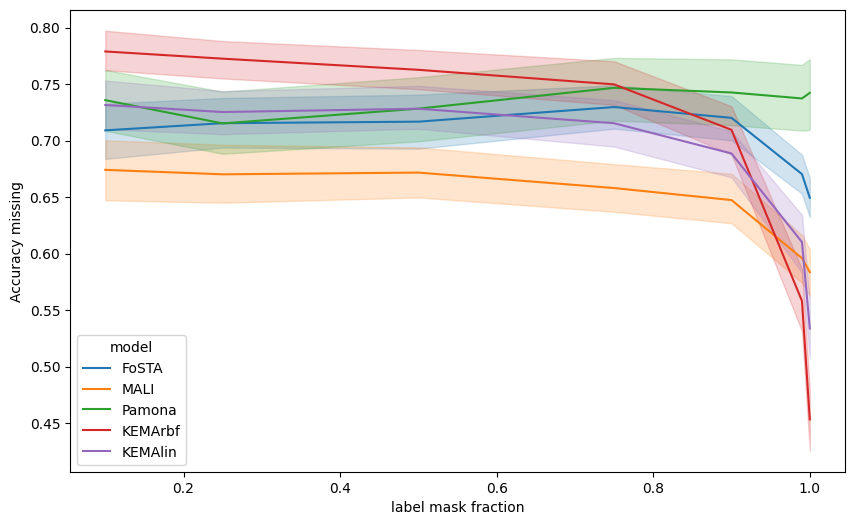

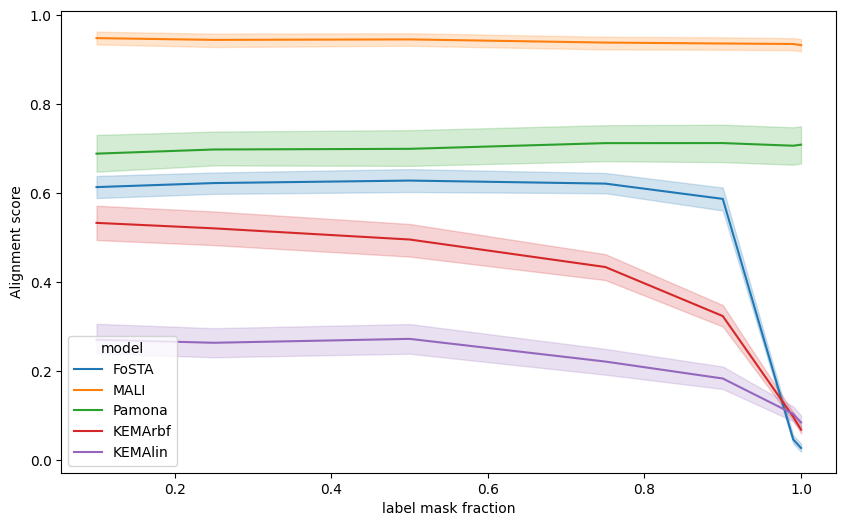

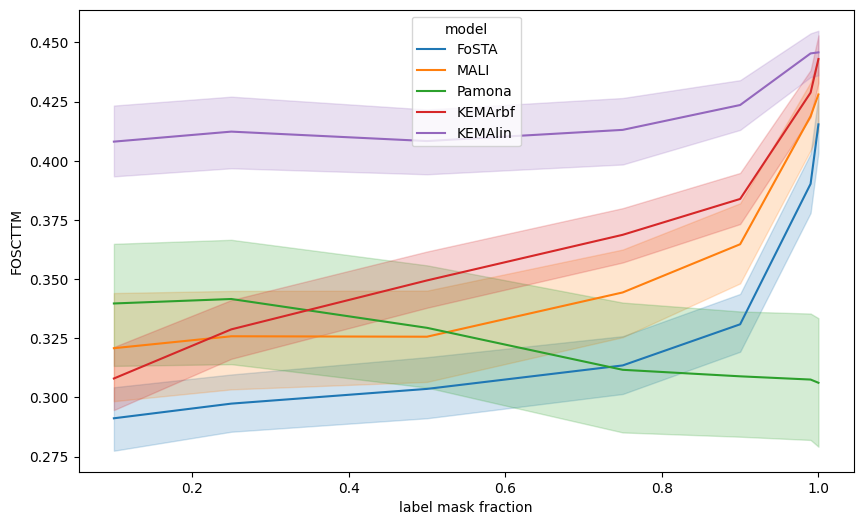

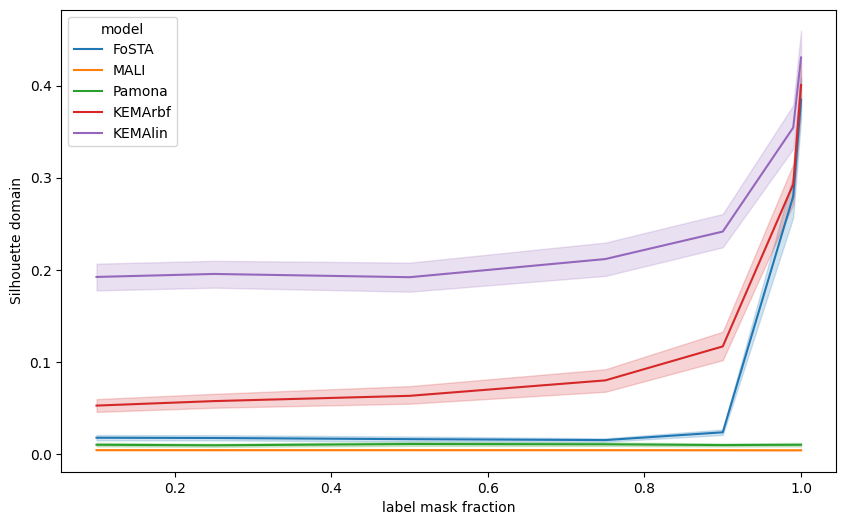

In [46]:
summary_df
cols_to_plot = ["Accuracy missing", "Alignment score", "FOSCTTM", "Silhouette domain"]
for col in cols_to_plot:
    plt.figure(figsize=(10,6))
    sns.lineplot(data=results_df, x='label mask fraction', y=col, hue='model')
    # sns.scatterplot(data=results_df, x='label mask fraction', y=col, hue='model')
    
    # if col == "Silhouette domain":
    #     plt.figure(figsize=(10,6))
    #     sns.lineplot(data=results_df[(results_df['model'] != "KEMArbf") & (results_df['model'] != "KEMAlin")], x='label mask fraction', y=col, hue='model')
    #     plt.show()

# memory and time

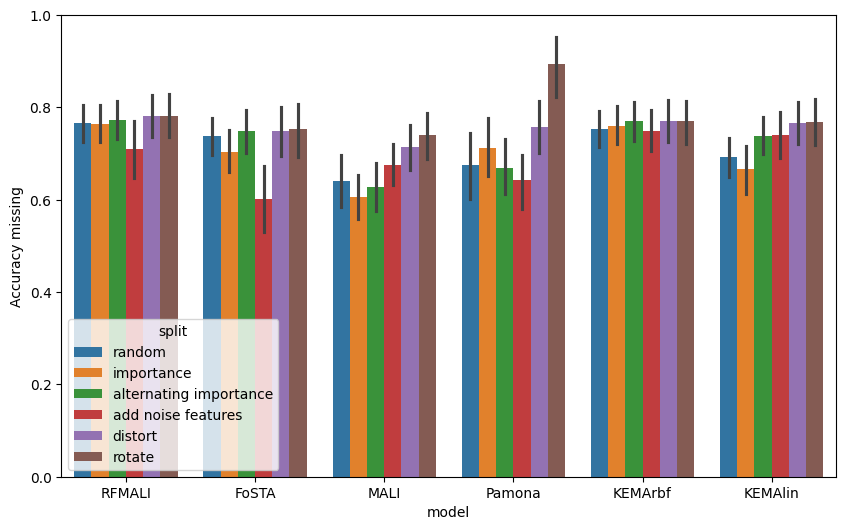

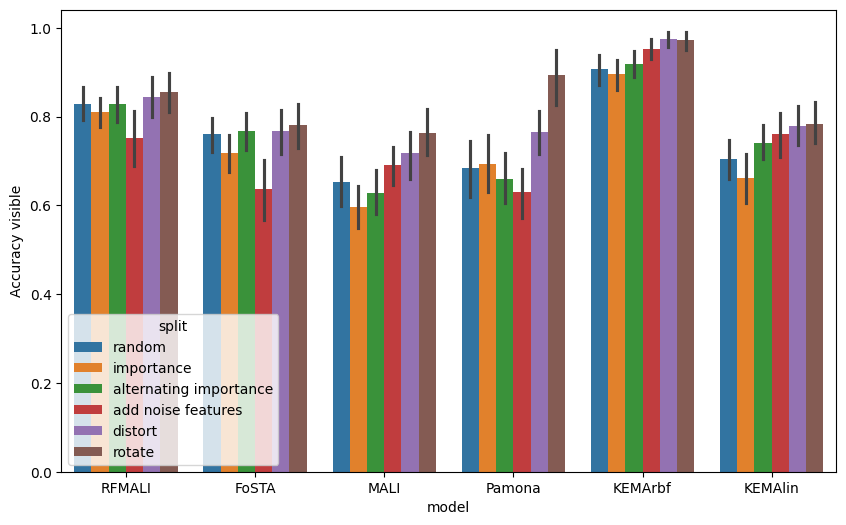

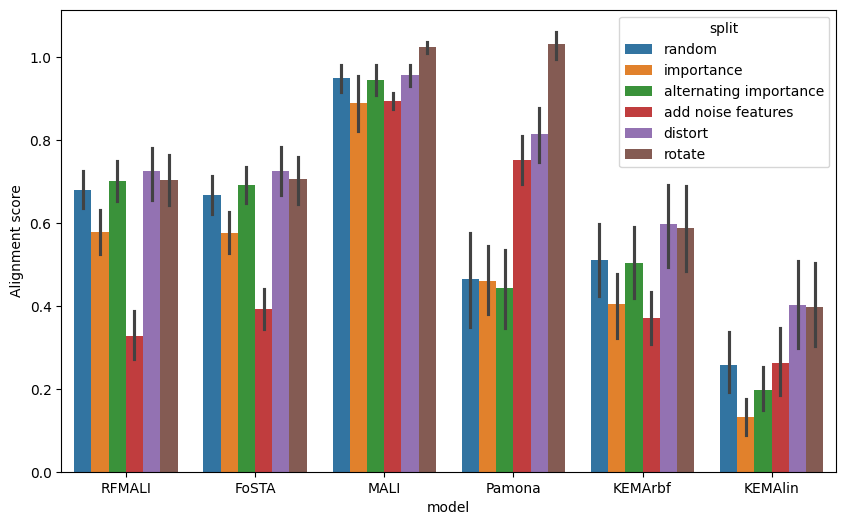

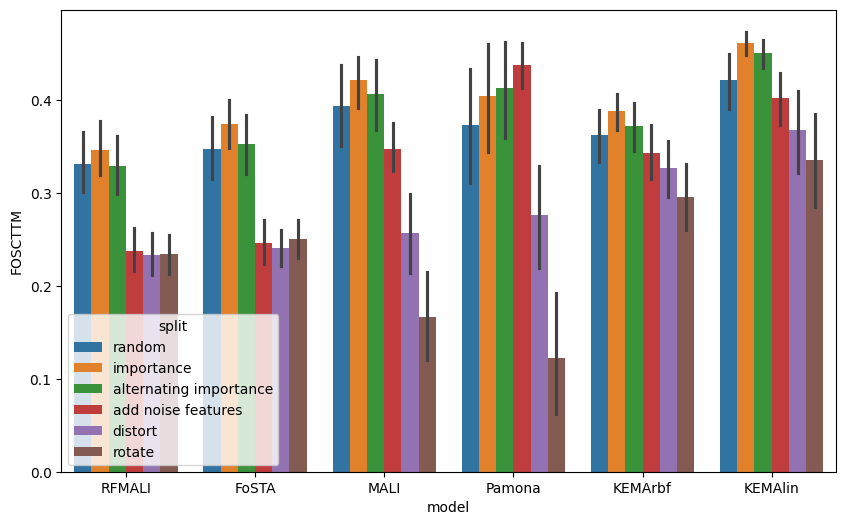

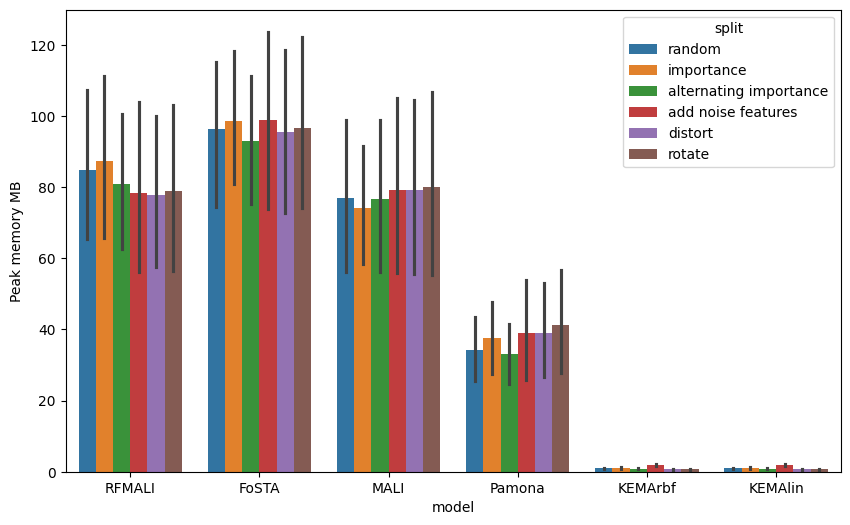

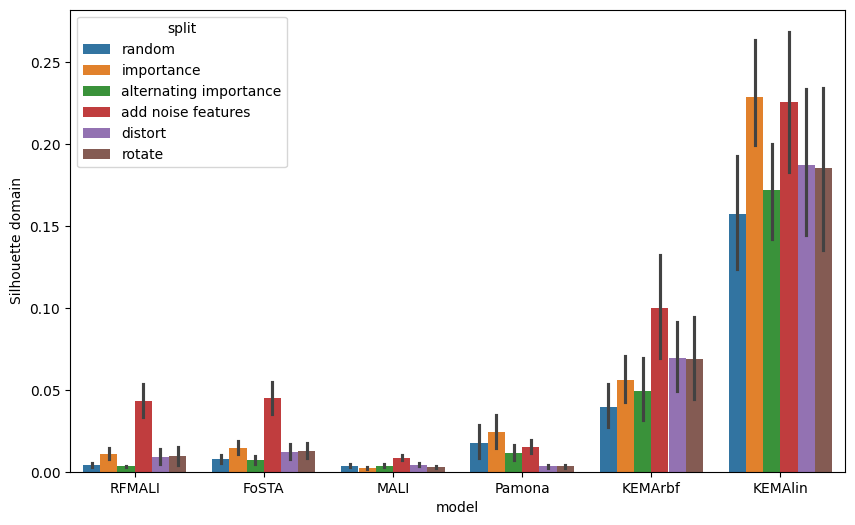

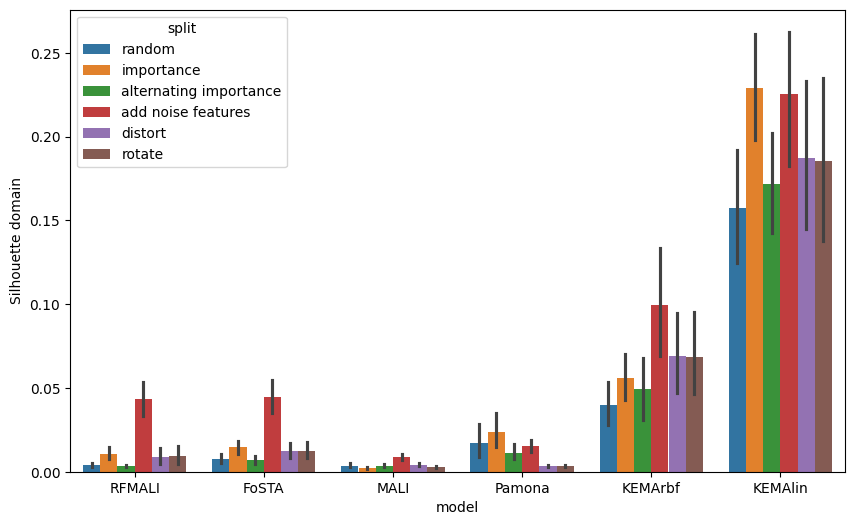

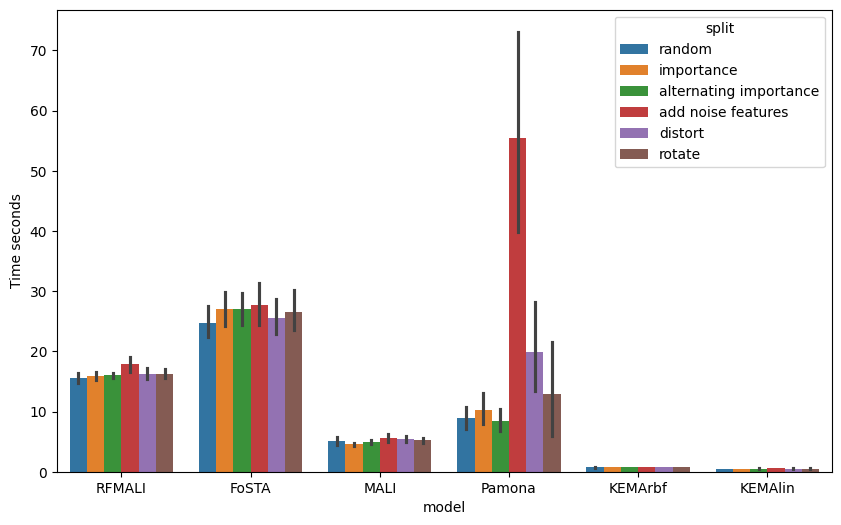

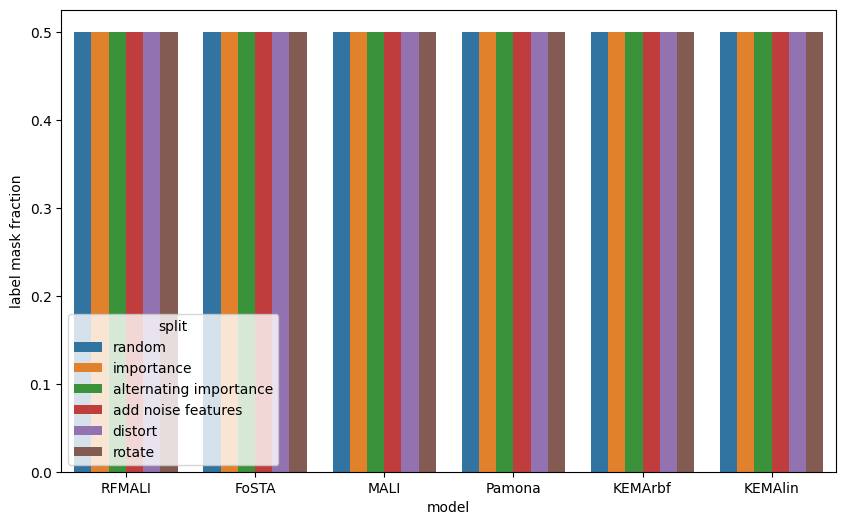

In [55]:
# subset to 0.5 label mask fraction
subset_df = results_df[results_df['label mask fraction'] == 0.5]

for col in num_cols:
    plt.figure(figsize=(10,6))
    sns.barplot(data=subset_df, x='model', y=col, hue='split')
    
    
    if col == "Silhouette domain":
        plt.figure(figsize=(10,6))
        sns.barplot(data=subset_df, x='model', y=col, hue='split')
        plt.show()